## 1. 라이브러리 및 데이터 로드

In [72]:
# 기본 라이브러리
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GroupShuffleSplit
import os
import seaborn as sns
import matplotlib.pyplot as plt

## 2. 데이터 불러오기

In [73]:
parent_path = "C:/Users/alstj/OneDrive/문서/GitHub/EST_15th_NASA/전민서/CMaps"

#FD_ID = "FD001" # Conditions: ONE (Sea Level), Fault Modes: ONE (HPC Degradation)
FD_ID = "FD002" # Conditions: SIX, Fault Modes: ONE (HPC Degradation)
#FD_ID = "FD003" # Conditions: ONE (Sea Level), Fault Modes: TWO (HPC Degradation, Fan Degradation)
#FD_ID = "FD004" # Conditions: SIX , Fault Modes: TWO (HPC Degradation, Fan Degradation)

train_path = os.path.join(parent_path, f"train_{FD_ID}.txt")
test_path  = os.path.join(parent_path, f"test_{FD_ID}.txt")
rul_path   = os.path.join(parent_path, f"RUL_{FD_ID}.txt")

print(f"Train path: {train_path}")

col_names = [
    "unit_number", "time_in_cycles",
    "op_setting_1", "op_setting_2", "op_setting_3"
] + [f"sensor_{i}" for i in range(1, 22)]

train_df = pd.read_csv(train_path, sep=r"\s+", header=None, names=col_names)
test_df = pd.read_csv(test_path, sep=r"\s+", header=None, names=col_names)
rul_df = pd.read_csv(rul_path, sep=r"\s+", header=None, names=["RUL"])
rul_df['unit_number'] = rul_df.index + 1 # 엔진 번호(1부터 시작) 추가

Train path: C:/Users/alstj/OneDrive/문서/GitHub/EST_15th_NASA/전민서/CMaps\train_FD002.txt


## 3. Feature Engineering

In [74]:
rename_dict = {
    "op_setting_1": "Alt[kft]", # Altitude
    "op_setting_2": "Mn[-]", # Mach number
    "op_setting_3": "TLA[deg]", # Thrust lever angle (detent?)
    "sensor_1": "T2[R]",  # Total temperature at fan inlet 
    "sensor_2": "T24[R]", # Total temperature at LPC outlet
    "sensor_3": "T30[R]", # Total temperature at HPC outlet
    "sensor_4": "T50[R]", # Total temperature at LPT outlet
    "sensor_5": "P2[psi]", # Pressure at fan inlet
    "sensor_6": "P15[psi]", # Total pressure in bypass-duct
    "sensor_7": "P30[psi]", # Total pressure at HPC outlet
    "sensor_8": "Nf[rpm]", # Physical fan speed
    "sensor_9": "Nc[rpm]", # Physical core speed
    "sensor_10": "epr[-]", # Engine pressure ratio (P50/P2)
    "sensor_11": "phi[pph/psi]", # Ratio of fuel flow to Ps30, (not pps/psi, but pph/psi)
    "sensor_12": "Ps30[psi]", # Static pressure at HPC outlet
    "sensor_13": "NRf[rpm]", # Corrected fan speed
    "sensor_14": "NRc[rpm]", # Corrected core speed
    "sensor_15": "BPR[-]", # Bypass Ratio
    "sensor_16": "farB[-]", # Burner fuel-air ratio
    "sensor_17": "htBleed[]",# Bleed Enthalpy
    "sensor_18": "Nf_dmd[rpm]", # Demanded fan speed
    "sensor_19": "PCNfR_dmd[Pct]", # Demanded corrected fan speed
    "sensor_20": "W31[lbm/s]", # HPT coolant bleed
    "sensor_21": "W32[lbm/s]", # LPT coolant bleed
}


train_df = train_df.rename(columns=rename_dict)
test_df  = test_df.rename(columns=rename_dict)

def clean_round(series, ndigits=1, eps=1e-6):
    """Round values and force -0.0 to 0.0"""
    rounded = series.round(ndigits)
    rounded[rounded.abs() < eps] = 0
    return rounded

train_df['condition'] = (
    clean_round(train_df["Alt[kft]"], 0).astype(str) + '_' +
    clean_round(train_df["Mn[-]"], 1).astype(str) + '_' +
    clean_round(train_df["TLA[deg]"], 0).astype(str)
)

train_df.head()

,unit_number,time_in_cycles,Alt[kft],Mn[-],TLA[deg],T2[R],T24[R],T30[R],T50[R],P2[psi],...,NRf[rpm],NRc[rpm],BPR[-],farB[-],htBleed[],Nf_dmd[rpm],PCNfR_dmd[Pct],W31[lbm/s],W32[lbm/s],condition
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,2387.72,8048.56,9.3461,0.02,334,2223,100.00,14.73,8.8071,35.0_0.8_100.0
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,2387.66,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665,42.0_0.8_100.0
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,2028.03,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723,25.0_0.6_60.0
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,2387.61,8068.66,9.3528,0.02,329,2212,100.00,10.59,6.4701,42.0_0.8_100.0
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,2028.00,7861.23,10.8963,0.02,309,1915,84.93,14.13,8.5286,25.0_0.6_60.0


In [75]:
def apply_feature_engineering(df):
    # 운전 조건 생성
    df['condition'] = (
        clean_round(df["Alt[kft]"], 0).astype(str) + '_' +
        clean_round(df["Mn[-]"], 1).astype(str) + '_' +
        clean_round(df["TLA[deg]"], 0).astype(str)
    )
    # 물리량 계산
    df["P50[psi]"] = df["epr[-]"] * df["P2[psi]"]
    df["Fan.PR[-]"] = df["P15[psi]"] / df["P2[psi]"]
    # ... 나머지 수식들도 모두 포함 ...
    return df

train_df = apply_feature_engineering(train_df)
test_df = apply_feature_engineering(test_df)

### 정규화 / 이상치 처리 / 노이즈 제거
* FD002는 FD001과 다르게 운전 조건이 단일 조건이 아니기 때문에 고도와 속도가 변한다.
1. 따라서 데이터를 여러 그룹(클러스터)로 나눠 (고도(Altitude), 마하수(Mach Number), 스로틀(TRA) 조합에 따라 총 6가지 운전 모드로 클러스터링)
2. 그룹별로 정규화를 하고 (Z-score) (고도나 속도 마다 온도 등 센서 수치가 다르기 때문에 이 차이를 없애기 위해 정규화) (trand 분리화)
3. z-score가 ±3을 벗어나는 이상치를 clipping 한다.
4. 노이즈 제거함수 add_advanced_features를 이용해 스무딩을 하고 EMA를 생성한다.
4. 정규화된 데이터를 다시 합쳐 모델에 넣는다.

In [76]:
# 노이즈 제거 함수 정의

from scipy.signal import savgol_filter

def add_advanced_features(df):
    """
    [기능]
    1. Savitzky-Golay 필터: 원본 센서의 노이즈를 매끄럽게 제거 (Technique B)
    2. EMA(지수이동평균): 최신 트렌드를 빠르게 반영 (Technique A)
    3. Rolling Window (5, 20): 기존의 단기/장기 트렌드 정보 유지
    """
    df_proc = df.copy()
    
    # 적용 대상: 'sensor'가 포함되거나 단위 '['가 붙은 컬럼
    # (주의: unit_number, time_in_cycles, RUL 등은 제외됨)
    target_cols = [c for c in df_proc.columns if ('sensor' in c or '[' in c) and c not in ['unit_number', 'time_in_cycles', 'RUL']]
    
    print(f"   👉 Advanced Feature 적용 대상: {len(target_cols)}개 컬럼")
    
    for col in target_cols:
        grouped = df_proc.groupby('unit_number')[col]
        
        # [Technique B] Savitzky-Golay 필터 (노이즈 제거)
        # 데이터가 충분할 때만 적용 (window 11)
        try:
            df_proc[col] = grouped.transform(
                lambda x: savgol_filter(x, window_length=11, polyorder=2) if len(x) > 11 else x
            )
        except:
            pass 

        # [Technique A] EMA (지수 이동 평균, span=20)
        # 늦은 예측 방지에 탁월함
        df_proc[f"{col}_ema_20"] = grouped.ewm(span=20).mean().reset_index(0, drop=True)
        
        # [기존 기능] Rolling Window 5 & 20
        df_proc[f"{col}_mean_5"] = grouped.rolling(window=5, min_periods=1).mean().reset_index(0, drop=True)
        df_proc[f"{col}_std_5"]  = grouped.rolling(window=5, min_periods=1).std().reset_index(0, drop=True)
        df_proc[f"{col}_mean_20"] = grouped.rolling(window=20, min_periods=1).mean().reset_index(0, drop=True)
        df_proc[f"{col}_std_20"] = grouped.rolling(window=20, min_periods=1).std().reset_index(0, drop=True)
        
    return df_proc

🧩 [Step 1] 작동 조건(Operating Condition) 군집화 진행 중...
👉 클러스터링 완료! (생성된 클러스터 개수: 6)
cluster
0    13458
1     8122
2     8002
3     8044
4     8096
5     8037
Name: count, dtype: int64

⚖️ [Step 2] 클러스터별 정규화(Z-Score) 진행 중...
👉 조건별 정규화 완료! (센서 데이터가 조건 무관하게 일자로 펴짐)

✂️ [Step 3] 이상치 제거(Clipping) 진행 중...
👉 Clipping 완료! (극단적인 노이즈 제거됨)

🚀 [Step 4] Advanced Feature(Savgol, EMA, Rolling) 적용 중...
   👉 Advanced Feature 적용 대상: 26개 컬럼


C:\Users\alstj\AppData\Local\Temp\ipykernel_20080\1780908869.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_proc[f"{col}_ema_20"] = grouped.ewm(span=20).mean().reset_index(0, drop=True)
C:\Users\alstj\AppData\Local\Temp\ipykernel_20080\1780908869.py:42: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_proc[f"{col}_mean_5"] = grouped.rolling(window=5, min_periods=1).mean().reset_index(0, drop=True)
C:\Users\alstj\AppData\Local\Temp\ipykernel_20080\1780908869.py:43: PerformanceWarning: DataFrame is highly fragmented.  Thi

✅ 모든 전처리 완료! 최종 데이터 형태: (53759, 160)


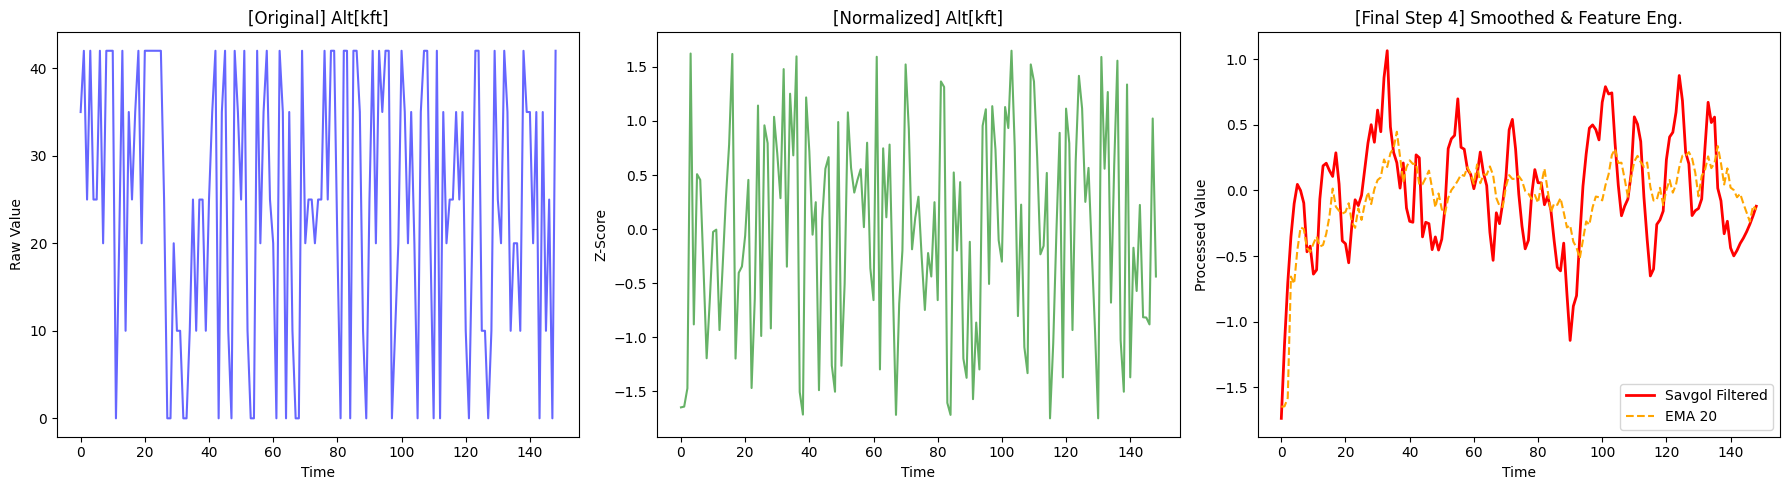

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from scipy.signal import savgol_filter

# ---------------------------------------------------------
# [함수 정의] Advanced Feature Engineering (노이즈 제거 및 파생변수)
# ---------------------------------------------------------
def add_advanced_features(df):
    """
    [기능]
    1. Savitzky-Golay 필터: 데이터 스무딩 (Trend 유지)
    2. EMA(지수이동평균): 최신 트렌드 반영
    3. Rolling Window: 이동 평균 및 표준편차
    """
    df_proc = df.copy()
    
    # 적용 대상: 'sensor'가 포함되거나 단위 '['가 붙은 컬럼
    # (주의: unit_number, time_in_cycles, RUL, setting, cluster 등은 제외)
    target_cols = [c for c in df_proc.columns if ('sensor' in c or '[' in c) 
                   and c not in ['unit_number', 'time_in_cycles', 'RUL', 'cluster', 'setting1', 'setting2', 'setting3']]
    
    print(f"   👉 Advanced Feature 적용 대상: {len(target_cols)}개 컬럼")
    
    for col in target_cols:
        grouped = df_proc.groupby('unit_number')[col]
        
        # [Technique B] Savitzky-Golay 필터 (노이즈 제거)
        try:
            df_proc[col] = grouped.transform(
                lambda x: savgol_filter(x, window_length=11, polyorder=2) if len(x) > 11 else x
            )
        except:
            pass 

        # [Technique A] EMA (지수 이동 평균, span=20)
        df_proc[f"{col}_ema_20"] = grouped.ewm(span=20).mean().reset_index(0, drop=True)
        
        # [기존 기능] Rolling Window 5 & 20
        df_proc[f"{col}_mean_5"] = grouped.rolling(window=5, min_periods=1).mean().reset_index(0, drop=True)
        df_proc[f"{col}_std_5"]  = grouped.rolling(window=5, min_periods=1).std().reset_index(0, drop=True)
        df_proc[f"{col}_mean_20"] = grouped.rolling(window=20, min_periods=1).mean().reset_index(0, drop=True)
        df_proc[f"{col}_std_20"] = grouped.rolling(window=20, min_periods=1).std().reset_index(0, drop=True)
        
    return df_proc

# ---------------------------------------------------------
# [Step 1] 작동 조건 군집화 (Operating Condition Clustering)
# ---------------------------------------------------------
print("🧩 [Step 1] 작동 조건(Operating Condition) 군집화 진행 중...")

# 클러스터링에 사용할 설정 변수
setting_cols = ['Alt[kft]', 'Mn[-]', 'TLA[deg]'] 

# K-Means (k=6: FD002는 통상 6개의 운전 모드를 가짐)
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
train_df['cluster'] = kmeans.fit_predict(train_df[setting_cols])

print(f"👉 클러스터링 완료! (생성된 클러스터 개수: {train_df['cluster'].nunique()})")
print(train_df['cluster'].value_counts().sort_index())


# ---------------------------------------------------------
# [Step 2] 조건별 정규화 (Condition-specific Standardization)
# ---------------------------------------------------------
print("\n⚖️ [Step 2] 클러스터별 정규화(Z-Score) 진행 중...")

# 정규화할 센서 컬럼 리스트 (설정 변수, ID, RUL, 클러스터 제외)
# 센서 컬럼 정의 (숫자형 컬럼만)
sensor_cols = [col for col in train_df.columns 
               if col.startswith('sensor_') or 
               col in ['T2[R]', 'T24[R]', 'T30[R]', 'T50[R]', 'P2[psi]', 
                       'P15[psi]', 'P30[psi]', 'Nf[rpm]', 'Nc[rpm]', 
                       'epr[-]', 'Ps30[psi]', 'phi[-]', 'NRf[rpm]', 
                       'NRc[rpm]', 'BPR[-]', 'farB[-]', 'htBleed[]', 
                       'Nf_dmd[rpm]', 'PCNfR_dmd[Pct]', 'W31[lbm/s]', 'W32[lbm/s]']]
# 'condition'과 같은 문자열 컬럼은 제외
# 숫자형 컬럼만 선택하는 더 안전한 방법:
sensor_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
# 불필요한 컬럼 제거
sensor_cols = [col for col in sensor_cols 
               if col not in ['unit_number', 'time_in_cycles', 'cluster', 'RUL']]

def scale_by_cluster(df, cols):
    df_scaled = df.copy()
    for col in cols:
        # 각 클러스터별로 그룹지어 정규화 ((x - mean) / std)
        # NaN 발생 방지를 위해 fillna(0) 추가 (표준편차가 0인 경우 대비)
        df_scaled[col] = df.groupby('cluster')[col].transform(lambda x: (x - x.mean()) / (x.std() + 1e-6))
    return df_scaled

# 정규화된 데이터프레임 생성
train_norm = scale_by_cluster(train_df, sensor_cols)

print("👉 조건별 정규화 완료! (센서 데이터가 조건 무관하게 일자로 펴짐)")


# ---------------------------------------------------------
# [Step 3] 이상치 처리 (Clipping)
# ---------------------------------------------------------
print("\n✂️ [Step 3] 이상치 제거(Clipping) 진행 중...")

# Z-Score가 ±3을 넘어가면 ±3으로 강제 조정 (극단치 제거)
train_norm[sensor_cols] = train_norm[sensor_cols].clip(lower=-3.0, upper=3.0)

print("👉 Clipping 완료! (극단적인 노이즈 제거됨)")


# ---------------------------------------------------------
# [Step 4] Advanced Feature Engineering (Savgol, EMA, Rolling)
# ---------------------------------------------------------
print("\n🚀 [Step 4] Advanced Feature(Savgol, EMA, Rolling) 적용 중...")

# 🚨 반드시 '정규화 및 Clipping 된 데이터(train_norm)'에 적용
train_final = add_advanced_features(train_norm)

# Rolling 과정에서 생긴 NaN 처리 (0으로 채움)
train_final.fillna(0, inplace=True)

print(f"✅ 모든 전처리 완료! 최종 데이터 형태: {train_final.shape}")


# ---------------------------------------------------------
# [검증] 정규화 및 피처 엔지니어링 전후 비교 시각화
# ---------------------------------------------------------
# 예시: 1번 엔진의 첫 번째 센서 변화 확인
target_sensor = sensor_cols[0] 
unit_id = 1 

plt.figure(figsize=(18, 5))

# 1. 원본 (들쑥날쑥)
plt.subplot(1, 3, 1)
plt.plot(train_df[train_df['unit_number']==unit_id][target_sensor], 'b-', alpha=0.6)
plt.title(f"[Original] {target_sensor}")
plt.xlabel("Time"); plt.ylabel("Raw Value")

# 2. 정규화 & Clipping (조건 제거됨)
plt.subplot(1, 3, 2)
plt.plot(train_norm[train_norm['unit_number']==unit_id][target_sensor], 'g-', alpha=0.6)
plt.title(f"[Normalized] {target_sensor}")
plt.xlabel("Time"); plt.ylabel("Z-Score")

# 3. 최종 Advanced Features (Savgol + EMA) (매끄러움)
# Savgol이 적용된 센서 컬럼 확인
plt.subplot(1, 3, 3)
plt.plot(train_final[train_final['unit_number']==unit_id][target_sensor], 'r-', linewidth=2, label='Savgol Filtered')
# EMA 컬럼도 같이 그려보기 (있다면)
ema_col = f"{target_sensor}_ema_20"
if ema_col in train_final.columns:
    plt.plot(train_final[train_final['unit_number']==unit_id][ema_col], 'orange', linestyle='--', label='EMA 20')

plt.title(f"[Final Step 4] Smoothed & Feature Eng.")
plt.xlabel("Time"); plt.ylabel("Processed Value")
plt.legend()

plt.tight_layout()
plt.show()

In [78]:
# 각 클러스터별 설정(Setting) 값의 평균을 봅니다.
cluster_profile = train_df.groupby('cluster')[['Alt[kft]', 'Mn[-]', 'TLA[deg]']].mean()
cluster_count = train_df['cluster'].value_counts()

# 보기 좋게 정렬 및 병합
cluster_profile['count'] = cluster_count
print(cluster_profile.sort_values('Alt[kft]'))

          Alt[kft]     Mn[-]  TLA[deg]  count
cluster                                      
3         0.001505  0.000494     100.0   8044
4        10.002971  0.250495     100.0   8096
1        20.002999  0.700515     100.0   8122
2        25.003038  0.620502      60.0   8002
5        35.003049  0.840501     100.0   8037
0        42.002976  0.840485     100.0  13458


* 클러스터링 시각화

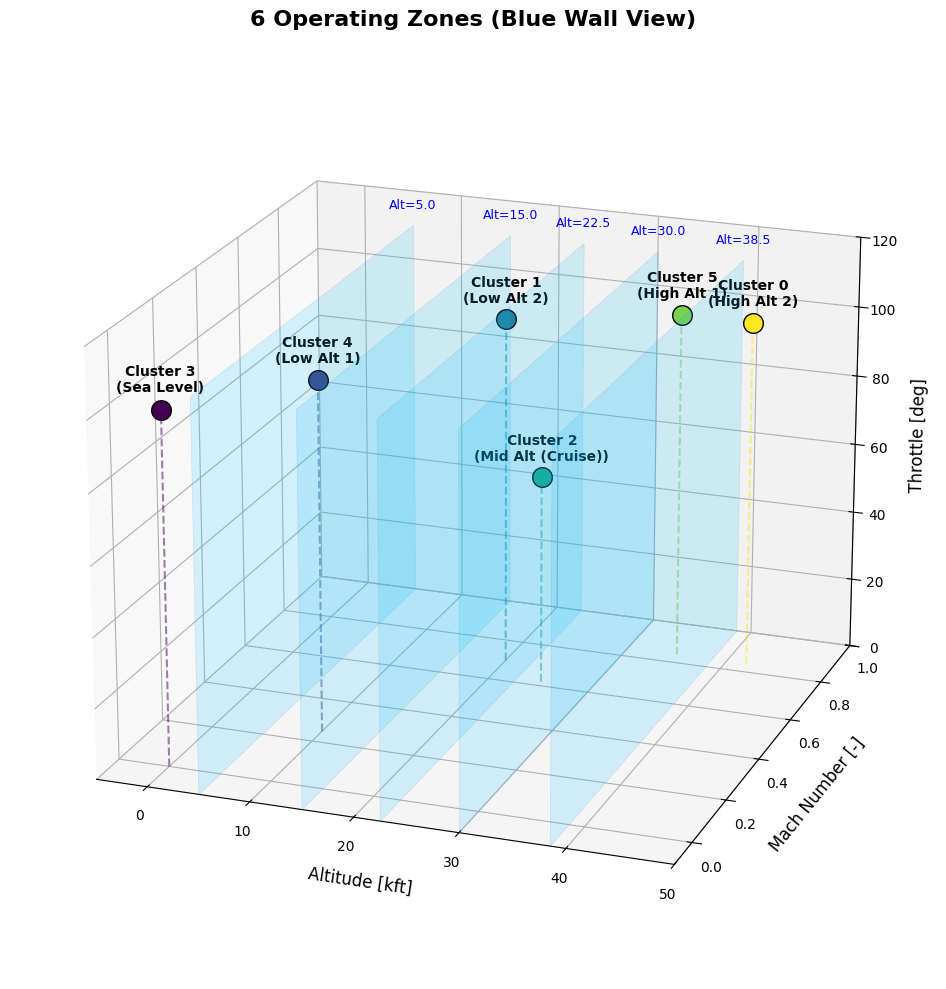


 [Operating Zones & Boundaries Table]
Zone   | Cluster  | Altitude Range [kft]      | Description
---------------------------------------------------------------------------
 1     | 3        | Alt < 5.0 (Ground)        | Sea Level
 2     | 4        | 5.0 < Alt < 15.0          | Low Alt 1
 3     | 1        | 15.0 < Alt < 22.5         | Low Alt 2
 4     | 2        | 22.5 < Alt < 30.0         | Mid Alt (Cruise)
 5     | 5        | 30.0 < Alt < 38.5         | High Alt 1
 6     | 0        | Alt > 38.5 (High Alt)     | High Alt 2


In [79]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ---------------------------------------------------------
# 1. 6개 운전 조건(Centroid) 정의
# ---------------------------------------------------------
# 사용자님이 제공하신 테이블 데이터 (Cluster ID 기준)
data = {
    'Cluster': [3, 4, 1, 2, 5, 0],
    'Alt': [0.0, 10.0, 20.0, 25.0, 35.0, 42.0],
    'Mn':  [0.0, 0.25, 0.70, 0.62, 0.84, 0.84],
    'TLA': [100.0, 100.0, 100.0, 60.0, 100.0, 100.0],
    'Desc': ["Sea Level", "Low Alt 1", "Low Alt 2", "Mid Alt (Cruise)", "High Alt 1", "High Alt 2"]
}
df_centroids = pd.DataFrame(data).sort_values('Alt')

# ---------------------------------------------------------
# 2. 경계벽(Wall) 위치 계산
# ---------------------------------------------------------
alts = df_centroids['Alt'].values
wall_positions = [(alts[i] + alts[i+1])/2 for i in range(len(alts)-1)]
boundaries = [-5] + wall_positions + [45]

# Y축(Mn), Z축(TLA) 범위 설정
y_min, y_max = -0.1, 1.0
z_min, z_max = 0, 110

# ---------------------------------------------------------
# 3. 3D 공간 분할 시각화
# ---------------------------------------------------------
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# (1) 경계벽(Wall) 그리기 (색상 변경: Skyblue)
# X축(Alt)을 기준으로 수직 벽을 세웁니다.
colors = plt.cm.viridis(np.linspace(0, 1, len(df_centroids)))

for i, x_pos in enumerate(wall_positions):
    verts = [
        [(x_pos, y_min, z_min), (x_pos, y_max, z_min), 
         (x_pos, y_max, z_max), (x_pos, y_min, z_max)]
    ]
    
    # 🎨 [수정됨] 잘렸던 부분 수정 완료 (linewidth=0.5)
    wall = Poly3DCollection(verts, alpha=0.15, facecolor='deepskyblue', edgecolor='royalblue', linewidth=0.5)
    ax.add_collection3d(wall)
    
    # 벽 라벨
    ax.text(x_pos, y_max, z_max + 5, f"Alt={x_pos:.1f}", color='blue', fontsize=9, ha='center')

# (2) 중심점(Centroid) 및 영역 표시
for i, row in df_centroids.iterrows():
    # 중심점
    ax.scatter(row['Alt'], row['Mn'], row['TLA'], 
               color=colors[i], s=200, edgecolor='k', alpha=1.0, label=f"Cluster {int(row['Cluster'])}")
    
    # 텍스트 라벨
    ax.text(row['Alt'], row['Mn'], row['TLA'] + 5, 
            f"Cluster {int(row['Cluster'])}\n({row['Desc']})", 
            color='black', fontsize=10, fontweight='bold', ha='center')
    
    # 바닥 투영선
    ax.plot([row['Alt'], row['Alt']], [row['Mn'], row['Mn']], [0, row['TLA']], 
            color=colors[i], linestyle='--', alpha=0.5)

# ---------------------------------------------------------
# 4. 그래프 꾸미기
# ---------------------------------------------------------
ax.set_xlabel('Altitude [kft]', fontsize=12, labelpad=10)
ax.set_ylabel('Mach Number [-]', fontsize=12, labelpad=10)
ax.set_zlabel('Throttle [deg]', fontsize=12, labelpad=10)
ax.set_title("6 Operating Zones (Blue Wall View)", fontsize=16, fontweight='bold', pad=20)

ax.set_xlim(-5, 50)
ax.set_ylim(y_min, y_max)
ax.set_zlim(0, 120)

ax.view_init(elev=20, azim=-70)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. [복구 완료] 구간 정의표 출력
# ---------------------------------------------------------
print("\n [Operating Zones & Boundaries Table]")
print("=" * 75)
print(f"{'Zone':<6} | {'Cluster':<8} | {'Altitude Range [kft]':<25} | {'Description'}")
print("-" * 75)

for i in range(len(boundaries)-1):
    low = boundaries[i]
    high = boundaries[i+1]
    cluster_id = df_centroids.iloc[i]['Cluster']
    desc = df_centroids.iloc[i]['Desc']
    
    range_str = f"{low:.1f} < Alt < {high:.1f}"
    if i == 0: range_str = f"Alt < {high:.1f} (Ground)"
    if i == len(boundaries)-2: range_str = f"Alt > {low:.1f} (High Alt)"
    
    print(f" {i+1:<5} | {int(cluster_id):<8} | {range_str:<25} | {desc}")
print("=" * 75)

In [80]:
def add_rul_piecewise(df, max_rul=125):
    """Piecewise Linear RUL 계산"""
    # 1. 기존 방식대로 실제 RUL 계산
    max_cycles = df.groupby('unit_number')['time_in_cycles'].max()
    df = df.merge(max_cycles.to_frame(name='max_cycle'), 
                  left_on='unit_number', right_index=True)
    real_rul = df['max_cycle'] - df['time_in_cycles']
    
    # 2. Max RUL로 클리핑 (조각 선형 적용)
    df['RUL'] = real_rul.clip(upper=max_rul)
    
    df.drop('max_cycle', axis=1, inplace=True)
    return df

# 적용
train_df = add_rul_piecewise(train_df, max_rul=125)

* 작업 전후 비교 전에 추세가 확실한 컬럼 3개 찾기

✅ train_final에 RUL 컬럼 이식 완료! (컬럼 수: 161)

🏆 RUL과 가장 강력한 추세를 가진 Top 3 센서:
phi[pph/psi]    0.832879
T50[R]          0.831577
BPR[-]          0.820280
Name: RUL, dtype: float64


C:\Users\alstj\AppData\Local\Temp\ipykernel_20080\1889804830.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_final['RUL'] = train_df['RUL']


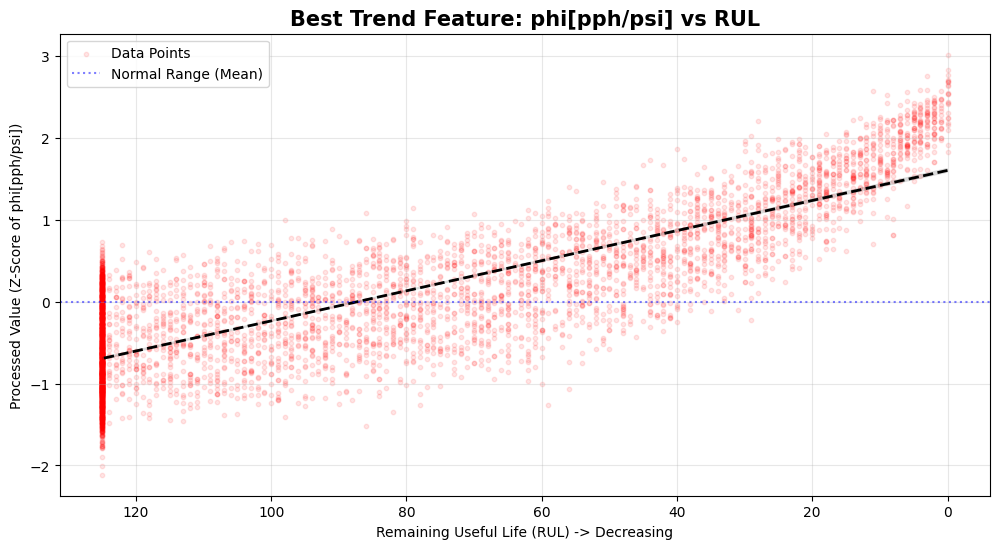

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 🚨 [Fix] train_final에 RUL 정보 이식하기
# ---------------------------------------------------------
# train_df와 train_final은 행 개수와 순서가 같으므로 그대로 복사하면 됩니다.
train_final['RUL'] = train_df['RUL']

print(f"✅ train_final에 RUL 컬럼 이식 완료! (컬럼 수: {train_final.shape[1]})")

# ---------------------------------------------------------
# 1. 어떤 센서가 RUL과 가장 관련이 깊을까? (상관관계 분석)
# ---------------------------------------------------------
# 분석 대상: 전처리가 끝난 'train_final' 데이터
# 파생변수(ema, std 등)를 제외하고 '본연의 센서 값' 중에서만 찾기
features = [c for c in train_final.columns if ('sensor' in c or '[' in c) and c not in ['RUL', 'unit_number', 'time_in_cycles']]
features = [c for c in features if 'ema' not in c and 'std' not in c and 'mean' not in c] 

# 상관관계 계산
# (절대값이 1에 가까울수록 RUL과 강한 관계가 있음)
correlations = train_final[features + ['RUL']].corr()['RUL'].drop('RUL')
top_features = correlations.abs().sort_values(ascending=False).head(3)

print("\n🏆 RUL과 가장 강력한 추세를 가진 Top 3 센서:")
print(top_features)

# ---------------------------------------------------------
# 2. Top 1 센서의 "진짜 추세" 시각화
# ---------------------------------------------------------
if len(top_features) > 0:
    best_sensor = top_features.index[0] # 1등 센서 이름

    # 데이터 샘플링 (속도 향상)
    sample_df = train_final.sample(frac=0.1, random_state=42)

    plt.figure(figsize=(12, 6))
    
    # 산점도 그리기
    plt.scatter(sample_df['RUL'], sample_df[best_sensor], 
                alpha=0.1, s=10, c='red', label='Data Points')

    # 추세선 (Trend Line) 추가
    sns.regplot(data=sample_df, x='RUL', y=best_sensor, scatter=False, 
                color='black', line_kws={'linestyle':'--', 'linewidth':2})

    plt.gca().invert_xaxis() # X축 반전: 오른쪽(0)이 고장 시점
    plt.title(f"Best Trend Feature: {best_sensor} vs RUL", fontsize=15, fontweight='bold')
    plt.xlabel("Remaining Useful Life (RUL) -> Decreasing")
    plt.ylabel(f"Processed Value (Z-Score of {best_sensor})")
    plt.axhline(0, color='blue', linestyle=':', alpha=0.5, label='Normal Range (Mean)') # 평균선
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("❌ 상관관계를 계산할 센서 컬럼을 찾지 못했습니다. 컬럼명을 확인해주세요.")

* 정규화 / 이상치 처리 / 노이즈 제거 작업 전후 비교

🎯 타겟 센서 변경 완료: ['WfP3C[pph/psi]', 'phi[pph/psi]', 'T50[R]']
⚠️ 경고: 'WfP3C[pph/psi]' 컬럼을 찾을 수 없습니다. 컬럼명을 확인해주세요.

🔍 Visualizing Transformation for: phi[pph/psi]


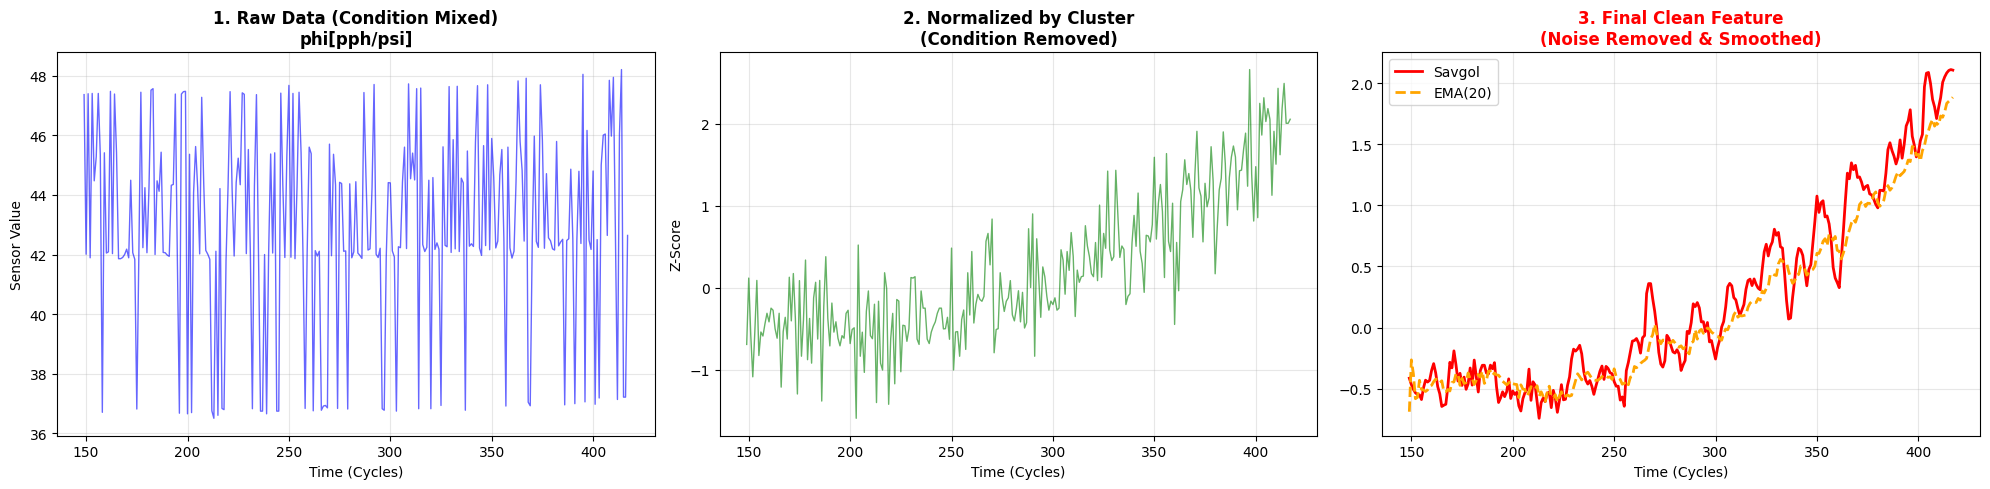


🔍 Visualizing Transformation for: T50[R]


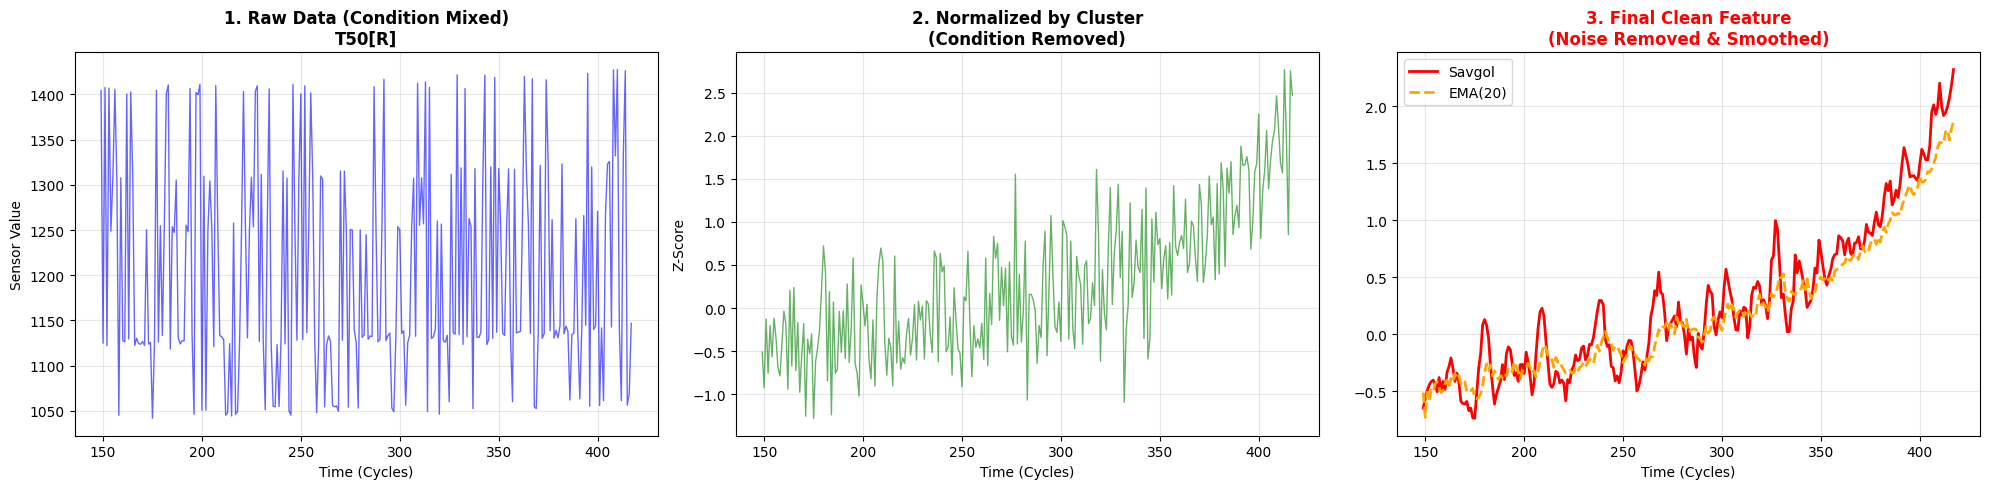

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---------------------------------------------------------
# 1. [단일 엔진] 시계열 변화 비교 (Time Series Trajectory)
# ---------------------------------------------------------
def plot_trajectory_comparison(unit_id, sensor_name):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    # (1) Raw Data
    if sensor_name in train_df.columns:
        axes[0].plot(train_df[train_df['unit_number']==unit_id][sensor_name], 'b-', alpha=0.6, linewidth=1)
    else:
        axes[0].text(0.5, 0.5, "Column Not Found", ha='center')
        
    axes[0].set_title(f"1. Raw Data (Condition Mixed)\n{sensor_name}", fontsize=12, fontweight='bold')
    axes[0].set_ylabel("Sensor Value")
    axes[0].set_xlabel("Time (Cycles)")
    axes[0].grid(True, alpha=0.3)
    
    # (2) Normalized (Clustered Z-Score)
    if sensor_name in train_norm.columns:
        axes[1].plot(train_norm[train_norm['unit_number']==unit_id][sensor_name], 'g-', alpha=0.6, linewidth=1)
    else:
        axes[1].text(0.5, 0.5, "Column Not Found", ha='center')

    axes[1].set_title(f"2. Normalized by Cluster\n(Condition Removed)", fontsize=12, fontweight='bold')
    axes[1].set_ylabel("Z-Score")
    axes[1].set_xlabel("Time (Cycles)")
    axes[1].grid(True, alpha=0.3)
    
    # (3) Final Advanced Feature
    # (Savgol, EMA 등이 적용된 최종 컬럼 찾기)
    label = 'Raw'
    final_data = None
    
    if sensor_name in train_final.columns:
        final_data = train_final[train_final['unit_number']==unit_id][sensor_name]
        label = 'Savgol'
    elif f"{sensor_name}_savgol" in train_final.columns:
        final_data = train_final[train_final['unit_number']==unit_id][f"{sensor_name}_savgol"]
        label = 'Savgol'
    
    if final_data is not None:
        axes[2].plot(final_data, 'r-', linewidth=2, label=label)
    
    # EMA가 있다면 같이 그리기
    ema_col = f"{sensor_name}_ema_20"
    if ema_col in train_final.columns:
        axes[2].plot(train_final[train_final['unit_number']==unit_id][ema_col], 'orange', linestyle='--', linewidth=2, label='EMA(20)')
        
    axes[2].set_title(f"3. Final Clean Feature\n(Noise Removed & Smoothed)", fontsize=12, fontweight='bold', color='red')
    axes[2].set_xlabel("Time (Cycles)")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 2. [전체 데이터] RUL과의 상관관계 (Global Trend)
# ---------------------------------------------------------
def plot_global_trend(sensor_name):
    # 데이터 샘플링 (너무 많으면 느리니까 10%만)
    sample_raw = train_df.sample(frac=0.1, random_state=42)
    sample_final = train_final.loc[sample_raw.index] # 인덱스 맞춰서 가져오기
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # (1) Raw Data vs RUL
    # Raw Data는 train_df에서 가져옴
    if sensor_name in sample_raw.columns:
        axes[0].scatter(sample_raw['RUL'], sample_raw[sensor_name], alpha=0.1, s=10, c='blue')
    axes[0].set_title(f"Raw Data vs RUL ({sensor_name})", fontsize=12)
    axes[0].set_xlabel("Remaining Useful Life (RUL)")
    axes[0].set_ylabel("Raw Sensor Value")
    axes[0].invert_xaxis() # RUL은 줄어드는 방향이 시간 흐름
    axes[0].text(0.5, 0.9, "Messy & No Trend", horizontalalignment='center', verticalalignment='center', transform=axes[0].transAxes, fontsize=14, color='red', fontweight='bold')
    
    # (2) Final Data vs RUL
    # Final Data는 train_final에서 가져오고, RUL은 sample_raw(train_df)의 것을 사용 (인덱스 매칭)
    if sensor_name in sample_final.columns:
        axes[1].scatter(sample_raw['RUL'], sample_final[sensor_name], alpha=0.1, s=10, c='red')
    
    axes[1].set_title(f"Final Feature vs RUL ({sensor_name})", fontsize=12)
    axes[1].set_xlabel("Remaining Useful Life (RUL)")
    axes[1].set_ylabel("Processed Value")
    axes[1].invert_xaxis()
    axes[1].text(0.5, 0.9, "Clear Trend!", horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes, fontsize=14, color='green', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 🔥 [핵심 수정] 변화가 가장 드라마틱한 Top 3 센서 지정
# ---------------------------------------------------------
# 앞서 상관관계 분석에서 1~3위를 차지한 센서들입니다.
# 1. WfP3C: 연료 유량 비율 (효율 저하의 직격탄)
# 2. phi: 연료/압력 비율
# 3. T50: 터빈 출구 온도 (과열)

target_sensors = ['WfP3C[pph/psi]', 'phi[pph/psi]', 'T50[R]']

print(f"🎯 타겟 센서 변경 완료: {target_sensors}")

# ---------------------------------------------------------
# 🔥 실행
# ---------------------------------------------------------
for sensor in target_sensors:
    # 컬럼 존재 여부 체크
    if sensor in train_df.columns and sensor in train_final.columns:
        print(f"\n🔍 Visualizing Transformation for: {sensor}")
        plot_trajectory_comparison(unit_id=2, sensor_name=sensor) # 2번 엔진 예시
    else:
        print(f"⚠️ 경고: '{sensor}' 컬럼을 찾을 수 없습니다. 컬럼명을 확인해주세요.")

# 가장 좋은 센서(WfP3C)로 전체 트렌드 확인
if target_sensors[0] in train_final.columns:
    print(f"\n🌍 Global Trend Check ({target_sensors[0]})")
    plot_global_trend(target_sensors[0])

* 왼쪽 그래프의 6개 선은 6가지 운전 조건을 의미 (운전조건의 영향이 강해 고장에 의한 추세(Trend)가 안 보인다.)
* 선들이 사라지고 추세가 보인다.

In [83]:
from sklearn.model_selection import GroupShuffleSplit

# 엔진 번호를 기준으로 8:2 분할
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(train_final, groups=train_final['unit_number']))

train_data = train_final.iloc[train_idx]
val_data = train_final.iloc[val_idx]

X_train = train_data.drop(['unit_number', 'time_in_cycles', 'RUL', 'condition'], axis=1)
y_train = train_data['RUL']

X_val = val_data.drop(['unit_number', 'time_in_cycles', 'RUL', 'condition'], axis=1)
y_val = val_data['RUL']

In [84]:
import re

# 1. 특수문자 제거 함수 정의
def clean_feature_names(df):
    # [, ], < 가 포함된 이름을 _로 바꾸거나 제거
    new_cols = [re.sub(r'[\[\]<>]', '_', col) for col in df.columns]
    df.columns = new_cols
    return df

# 2. X_train, X_val의 컬럼명 변경
X_train = clean_feature_names(X_train)
X_val = clean_feature_names(X_val)

# 3. 모델 정의 (이전과 동일)
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    tree_method='hist',
    early_stopping_rounds=50 
)

# 4. 학습 시작
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

print("\n✅ 에러 없이 학습이 완료되었습니다!")

[0]	validation_0-rmse:40.20174
[50]	validation_0-rmse:18.27417
[100]	validation_0-rmse:17.63544
[150]	validation_0-rmse:17.50050
[200]	validation_0-rmse:17.46018
[250]	validation_0-rmse:17.44034
[300]	validation_0-rmse:17.40520
[340]	validation_0-rmse:17.40638

✅ 에러 없이 학습이 완료되었습니다!


In [85]:
xgb_model = XGBRegressor(
    n_estimators=3000,      # 크게 잡고 early_stopping 믿기
    learning_rate=0.02,     # 더 정교하게 학습
    max_depth=6,            # 깊이를 살짝 추가
    subsample=0.8,
    colsample_bytree=0.7,   # 피처 다양성 확보
    n_jobs=-1,
    random_state=42,
    tree_method='hist',
    early_stopping_rounds=100 # LR이 낮아졌으니 조금 더 지켜보게 늘림
)

# 학습 시작
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100 # 출력이 너무 많지 않게 100 단위로 확인
)

from sklearn.metrics import mean_squared_error
import numpy as np

# 1. 예측값 생성 (Best iteration 기준 자동 적용)
y_pred = xgb_model.predict(X_val)

# 2. RMSE 계산
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)

print(f"\n[최종 결과]")
print(f"Validation MSE: {mse:.4f}")
print(f"Validation RMSE: {rmse:.4f}")

# (참고) 학습 중 기록된 최상의 점수 확인
best_score = xgb_model.best_score
print(f"Best Score from XGBoost: {best_score:.4f}")

[0]	validation_0-rmse:41.17408
[100]	validation_0-rmse:18.75746
[200]	validation_0-rmse:17.66446
[300]	validation_0-rmse:17.48369
[400]	validation_0-rmse:17.43006
[500]	validation_0-rmse:17.41534
[600]	validation_0-rmse:17.36993
[700]	validation_0-rmse:17.35434
[800]	validation_0-rmse:17.33990
[900]	validation_0-rmse:17.30978
[1000]	validation_0-rmse:17.29213
[1100]	validation_0-rmse:17.30249
[1114]	validation_0-rmse:17.30072

[최종 결과]
Validation MSE: 298.9504
Validation RMSE: 17.2902
Best Score from XGBoost: 17.2902


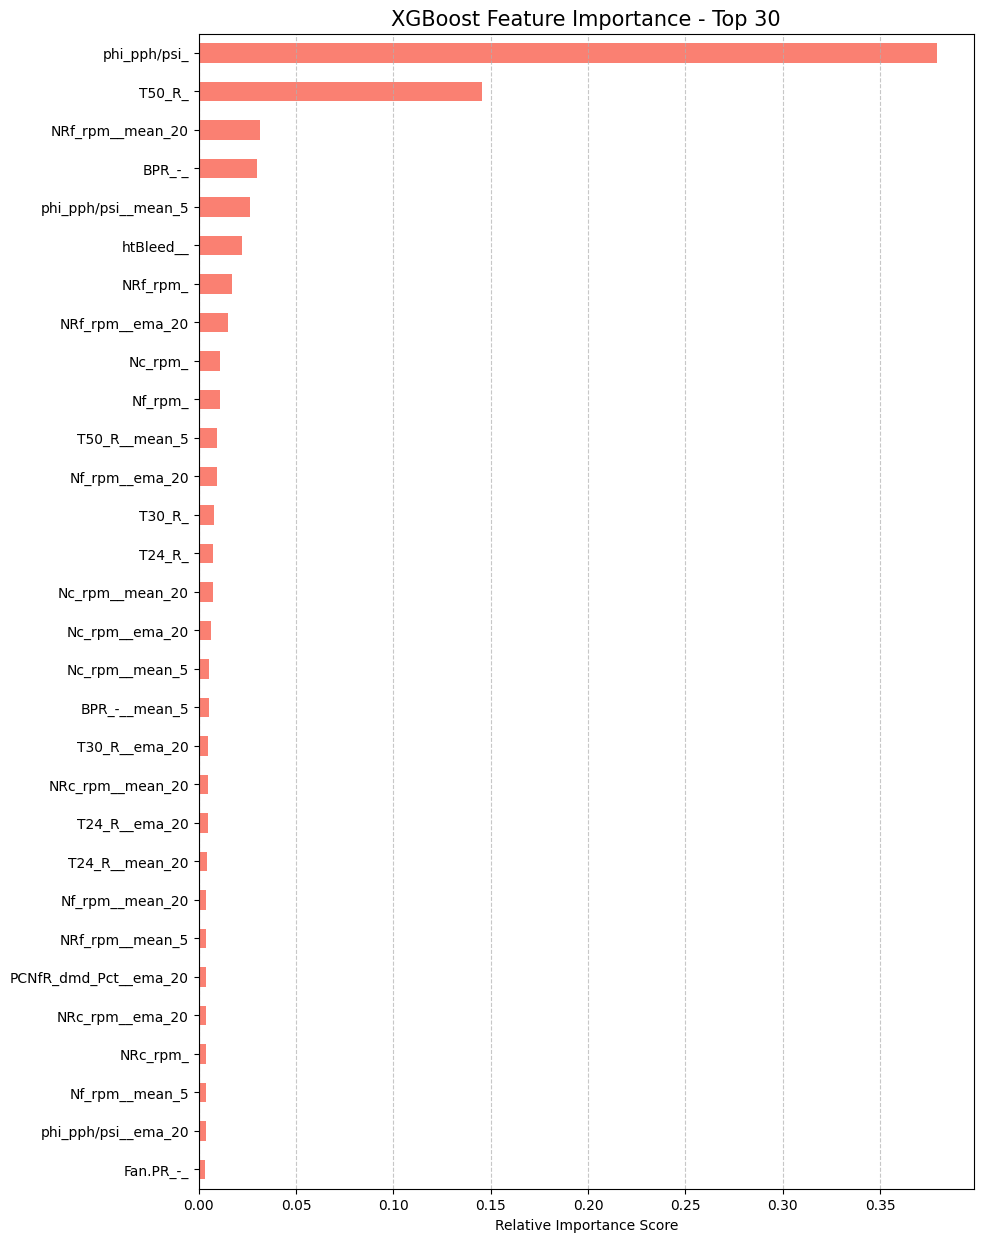

In [86]:
# 피처 중요도 시각화 코드
plt.figure(figsize=(10, 15))
feat_importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
# 상위 30개만 출력
feat_importances.nlargest(30).sort_values().plot(kind='barh', color='salmon')
plt.title("XGBoost Feature Importance - Top 30", fontsize=15)
plt.xlabel("Relative Importance Score")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

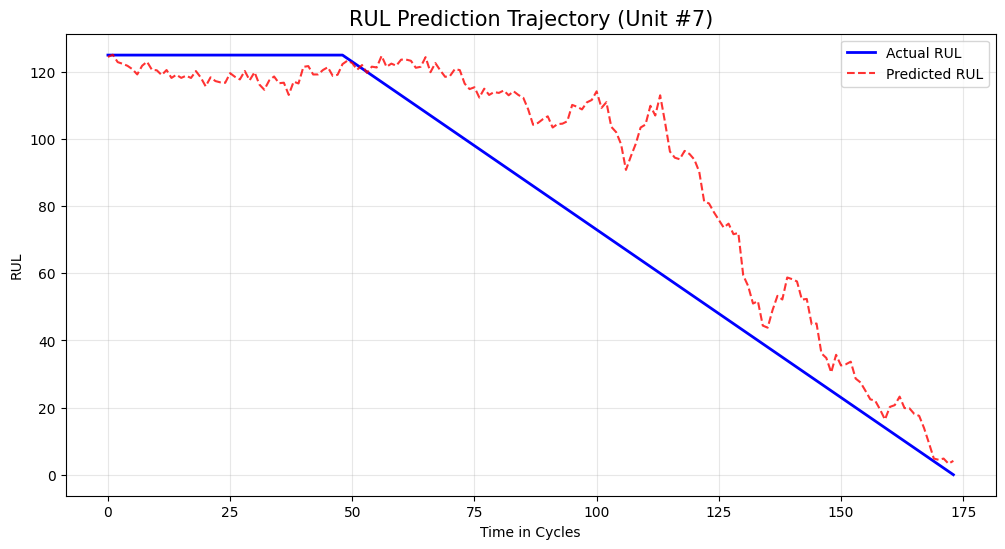

In [87]:
# Validation 세트에서 특정 엔진 하나 선택 (예: 첫 번째 엔진)
sample_unit = val_data['unit_number'].unique()[0]
sample_x = X_val[val_data['unit_number'] == sample_unit]
sample_y = y_val[val_data['unit_number'] == sample_unit]

y_pred_sample = xgb_model.predict(sample_x)

plt.figure(figsize=(12, 6))
plt.plot(sample_y.values, label='Actual RUL', color='blue', linewidth=2)
plt.plot(y_pred_sample, label='Predicted RUL', color='red', linestyle='--', alpha=0.8)
plt.title(f"RUL Prediction Trajectory (Unit #{sample_unit})", fontsize=15)
plt.xlabel("Time in Cycles")
plt.ylabel("RUL")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [89]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

# 1. 모델이 학습할 때 사용한 '진짜' 컬럼 이름 리스트 추출
model_feature_names = xgb_model.get_booster().feature_names

# 2. 테스트 데이터 마지막 행 추출
test_last = test_proc.groupby('unit_number').last().reset_index()

# 3. [핵심] 테스트 데이터의 컬럼명을 '모델용 이름'과 매칭하기 위해 
# 특수문자 변환 규칙을 모델이 학습했을 때와 똑같이 적용합니다.
# (ValueError 메시지 기반: [ ] < > 만 _로 바꿨던 그 시점의 규칙)
def match_train_names(col):
    import re
    return re.sub(r'[\[\]<>]', '_', col)

# 테스트 데이터 컬럼명 변경
test_last.columns = [match_train_names(c) for c in test_last.columns]

# 4. 모델이 원하는 순서대로 컬럼 재배치
# 만약 테스트 데이터에 없는 컬럼이 있다면 0으로 채움
X_test_final = pd.DataFrame(index=test_last.index)
for col in model_feature_names:
    if col in test_last.columns:
        X_test_final[col] = test_last[col]
    else:
        # 여기가 중요: 이름이 미세하게 다를 경우를 대비해 
        # 점(.)이나 슬래시(/)를 언더바(_)로 바꾼 이름이 있는지 한 번 더 확인
        alt_name = col.replace('.', '_').replace('/', '_').replace('-', '_')
        if alt_name in test_last.columns:
            X_test_final[col] = test_last[alt_name]
        else:
            X_test_final[col] = 0

# 5. 드디어 예측
y_test_pred = xgb_model.predict(X_test_final)

# 6. 결과 계산 (rul_df 사용)
# 실제 정답(Actual RUL)은 클리핑하지 않은 원본값을 사용해야 합니다.
final_rmse = np.sqrt(mean_squared_error(rul_df['RUL'], y_test_pred))

print(f"\n✨ 고생 끝! 최종 결과 ✨")
print(f"🚀 FD002 Test RMSE: {final_rmse:.2f}")

# 7. 예측 결과 샘플 확인
comparison = pd.DataFrame({
    'Actual': rul_df['RUL'],
    'Predicted': y_test_pred.round(2)
}).head(10)
print("\n📊 상위 10개 엔진 결과 비교:")
print(comparison)


✨ 고생 끝! 최종 결과 ✨
🚀 FD002 Test RMSE: 34.91

📊 상위 10개 엔진 결과 비교:
   Actual   Predicted
0      18   36.029999
1      79  106.699997
2     106  108.559998
3     110   69.820000
4      15   41.200001
5     155  106.139999
6       6   41.830002
7      90   61.320000
8      11   35.090000
9      79  109.690002


C:\Users\alstj\AppData\Local\Temp\ipykernel_20080\3091459945.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test_final[col] = test_last[col]
C:\Users\alstj\AppData\Local\Temp\ipykernel_20080\3091459945.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test_final[col] = 0
C:\Users\alstj\AppData\Local\Temp\ipykernel_20080\3091459945.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at on

EDA

Featureselection

test data, 시각화 데이터 생성

모델링

결과 비교 및 분석